# Prepare PF spatial-annotation references

This notebook is a lightly reorganized version of the reference-preparation workflow used in the original analysis. It shows how condition-restricted cell types were identified and how the normal and pulmonary-fibrosis (PF) reference atlases were sampled.

## Data

Download and extract the modular archives from the [UniGeneX PF Zenodo record](https://doi.org/10.5281/zenodo.22489310). Set `UNIGENEX_DATA_DIR` to the extracted directory containing `PF/`. This notebook uses `PF/UGE_atlas.h5ad`. If the variable is unset, it looks for `./data/PF/UGE_atlas.h5ad`.

## Key parameters

This notebook records how the two condition-specific mapping references were prepared. It is a provenance notebook rather than the recommended way to regenerate the exact released files.

| Setting | Manuscript value | Meaning |
|---|---:|---|
| Condition-specificity cutoff | `0.95` | A cell type with at least 95% adjusted support in one condition is excluded from the opposite-condition reference. |
| Reference sampling fraction | `1/5` of the atlas | Number of cells sampled independently before condition-restricted cell types are removed. |
| Random seed | not recorded | The historical subsampling cannot be reproduced cell-for-cell from this notebook alone. |
| Reference writing | disabled | Prevents accidental replacement of the canonical reference files. |

For exact mapping reproduction, use the normal and PF reference files and their matching nearest-neighbor caches supplied with the reproducibility data.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

DATA_ROOT = Path(
    os.environ.get("UNIGENEX_DATA_DIR", Path.cwd() / "data")
).expanduser().resolve()
PF_DATA_DIR = DATA_ROOT / "PF"
ATLAS_PATH = PF_DATA_DIR / "UGE_atlas.h5ad"

if not ATLAS_PATH.is_file():
    raise FileNotFoundError(
        f"UGE atlas not found: {ATLAS_PATH}\n"
        "Set UNIGENEX_DATA_DIR to the directory containing PF/."
    )

In [2]:
atlas_adata = sc.read_h5ad(ATLAS_PATH)
print(f"PF UGE atlas: {atlas_adata.n_obs:,} cells × {atlas_adata.n_vars:,} genes")
atlas_adata

PF UGE atlas: 946,364 cells × 1,741 genes


AnnData object with n_obs × n_vars = 946364 × 1741
    obs: 'cell_type', 'cell_id', 'dataset_idx', 'dataset_cell_id', 'ann_finest_level', 'dataset', 'ann_level_1', 'disease', 'original_ann_nonharmonized', 'leiden_2p0', 'leiden_2p5', 'leiden_1p5', 'leiden_0p5', 'leiden_1p0', 'leiden_0p5_ct_v0', 'leiden_1p0_ct_v0', 'leiden_2p5_ct_v0', 'tmp', 'leiden_2p5_epi_v1', 'leiden_2p5_epi', 'leiden_2p5_epi_v2', 'leiden_2p5_epi_v3', 'leiden_2p5_epi_v7', 'leiden_2p5_epi_v4', 'leiden_1p_fibro_v1', 'ct_anno'
    uns: 'ann_finest_level_colors', 'dataset_colors', 'disease_colors', 'leiden_2p0_colors', 'leiden_2p5_colors', 'leiden_2p5_ct_v0_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

## Identify condition-restricted cell types

For each final cell type (`ct_anno`), cell counts are first normalized by the total number of cells in each condition and then normalized across conditions. Cell types with at least 95% adjusted support in one condition are removed from the reference representing the other condition.

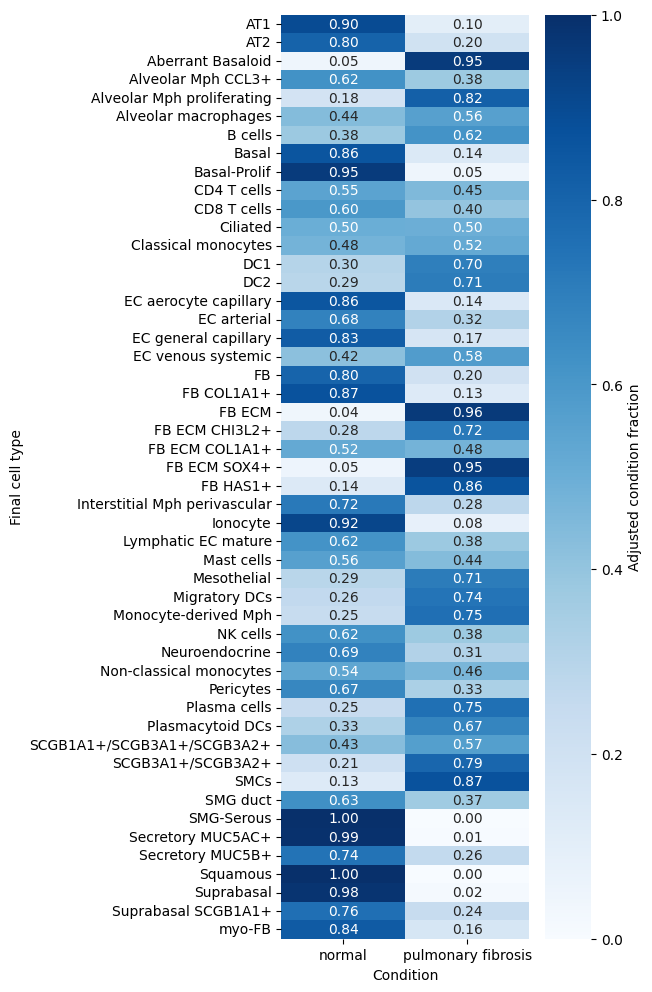

In [3]:
df_ct = pd.crosstab(atlas_adata.obs["ct_anno"], atlas_adata.obs["disease"])
df_ct = df_ct.div(atlas_adata.obs["disease"].value_counts(), axis="columns")
df_ct = df_ct.div(df_ct.sum(axis=1), axis="index")
df_ct = df_ct.loc[:, ["normal", "pulmonary fibrosis"]]

plt.figure(figsize=(4, 12))
sns.heatmap(
    df_ct,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Adjusted condition fraction"},
)
plt.xlabel("Condition")
plt.ylabel("Final cell type")
plt.show()
plt.close()

In [4]:
disease_rm_cts = df_ct.index[df_ct["normal"] >= 0.95].tolist()
normal_rm_cts = df_ct.index[
    df_ct["pulmonary fibrosis"] >= 0.95
].tolist()

print("Excluded from the PF reference:", disease_rm_cts)
print("Excluded from the normal reference:", normal_rm_cts)

Excluded from the PF reference: ['Basal-Prolif', 'SMG-Serous', 'Secretory MUC5AC+', 'Squamous', 'Suprabasal']
Excluded from the normal reference: ['Aberrant Basaloid', 'FB ECM']


## Subsample the two references

Following the original workflow, one fifth of the complete atlas is sampled independently for each reference. Condition-restricted cell types are then removed from the corresponding sampled atlas.

In [5]:
def subsample_data(adata, subsample_cell_num):
    subsample_index = np.random.choice(
        np.arange(adata.n_obs),
        subsample_cell_num,
        replace=False,
    )
    return adata[subsample_index, :].copy()


subsample_cell_num = atlas_adata.n_obs // 5

atlas_adata_disease = subsample_data(atlas_adata, subsample_cell_num)
atlas_adata_disease = atlas_adata_disease[
    ~atlas_adata_disease.obs["ct_anno"].isin(disease_rm_cts)
].copy()

atlas_adata_normal = subsample_data(atlas_adata, subsample_cell_num)
atlas_adata_normal = atlas_adata_normal[
    ~atlas_adata_normal.obs["ct_anno"].isin(normal_rm_cts)
].copy()

print("PF reference shape:", atlas_adata_disease.shape)
print("Normal reference shape:", atlas_adata_normal.shape)

PF reference shape: (178878, 1741)
Normal reference shape: (188646, 1741)


In [6]:
reference_celltype_counts = pd.DataFrame({
    "Disease": atlas_adata_disease.obs["ct_anno"].value_counts(),
    "Normal": atlas_adata_normal.obs["ct_anno"].value_counts(),
}).fillna(0).astype(int)

reference_celltype_counts

,Disease,Normal
ct_anno,,
AT1,3667,3689
AT2,19264,19219
Aberrant Basaloid,137,0
Alveolar Mph CCL3+,1037,1038
Alveolar Mph proliferating,391,354
Alveolar macrophages,24498,24624
B cells,3768,3787
Basal,13288,12983
Basal-Prolif,0,598


## Save reference files (disabled)

The original workflow wrote the two sampled objects as `atlas_Disease.h5ad` and `atlas_Normal.h5ad`. For provenance, the original write operations are shown in the next cell. Both commands are intentionally commented out, so running the notebook reports the intended output paths without saving files or overwriting the exact canonical references supplied through Zenodo.

In [7]:
reference_dir = PF_DATA_DIR / "spatial_annotation" / "Reference_data"
disease_reference_path = reference_dir / "atlas_Disease.h5ad"
normal_reference_path = reference_dir / "atlas_Normal.h5ad"

print("Reference writing is disabled.")
print("PF reference would be written to:", disease_reference_path.relative_to(DATA_ROOT))
print("Normal reference would be written to:", normal_reference_path.relative_to(DATA_ROOT))

# atlas_adata_disease.write_h5ad(disease_reference_path)
# atlas_adata_normal.write_h5ad(normal_reference_path)

Reference writing is disabled.
PF reference would be written to: PF/spatial_annotation/Reference_data/atlas_Disease.h5ad
Normal reference would be written to: PF/spatial_annotation/Reference_data/atlas_Normal.h5ad


## Use the released references for mapping

The original random subsampling did not record a random seed. The cells sampled above therefore illustrate the preparation procedure but are not expected to be identical to the references used in the manuscript.

For exact reuse, Zenodo provides the original reference files at `PF/spatial_annotation/Reference_data/atlas_Normal.h5ad` and `atlas_Disease.h5ad`, together with their matching fitted NN caches. `transformer_map_to_atlas.sh` uses those supplied files directly. If a new reference is generated, its PCA and NN cache must also be refitted.